C:\Users\Abhishek\AppData\Local\Temp\ipykernel_14464\2957731304.py:77: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(gdf.centroid.x, gdf.centroid.y, gdf["State_UT"]):


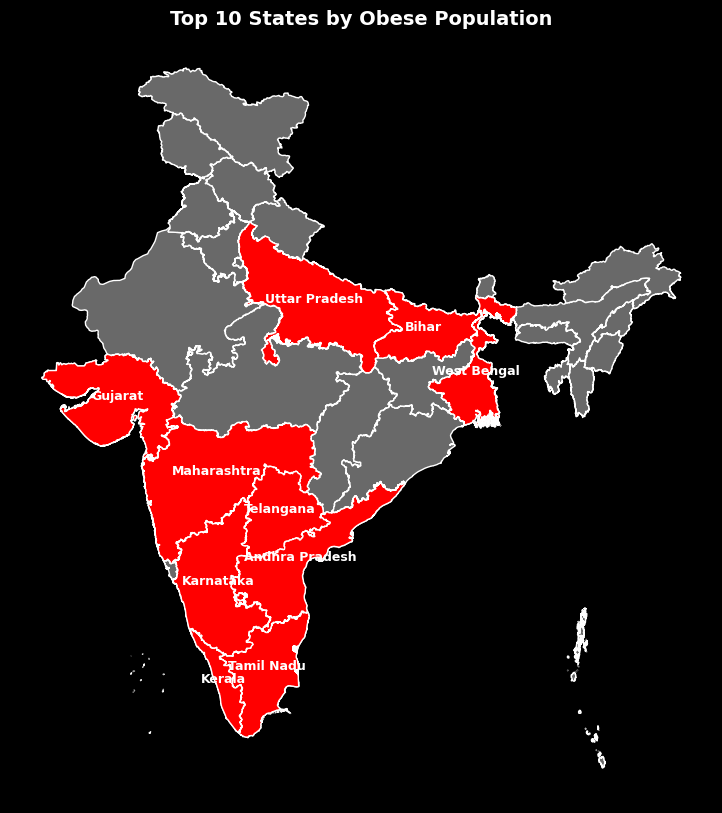

C:\Users\Abhishek\AppData\Local\Temp\ipykernel_14464\2957731304.py:96: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(gdf.centroid.x, gdf.centroid.y, gdf["State_UT"]):


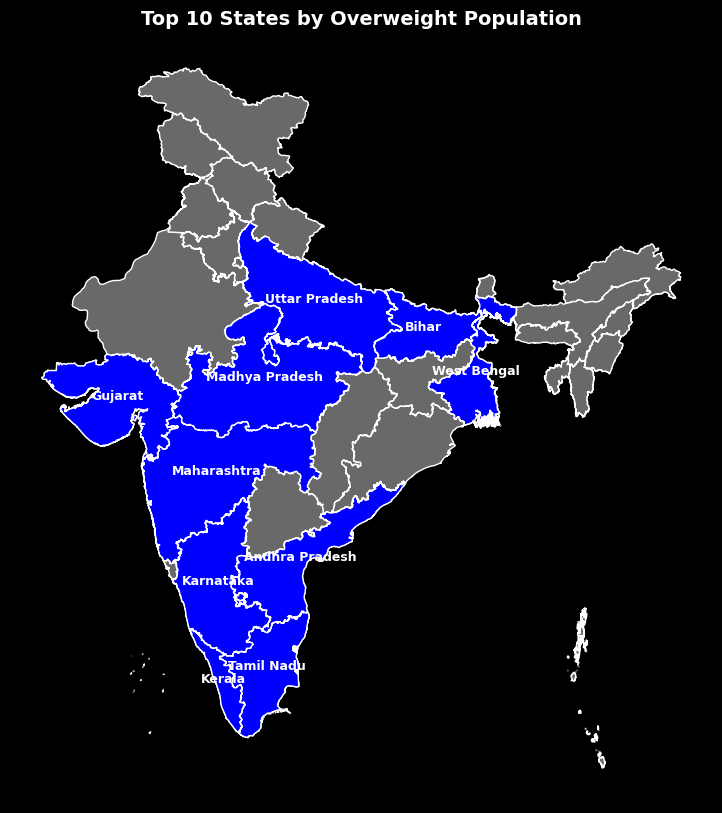

In [3]:
# =====================
# 1. Load Excel data
# =====================
import pandas as pd
import geopandas as gpd
import unicodedata
import matplotlib.pyplot as plt

# Load Excel
df = pd.read_excel(r"C:\Users\Abhishek\Desktop\Msc in Data Science\Novo Nordisk GBS Hackathon 2025\data.xlsx")

# Remove India row
df_states = df[df["State_UT"] != "India"].copy()

# Standardize names in Excel
df_states["State_UT"] = df_states["State_UT"].str.strip().str.title()


# =====================
# 2. Load shapefile of India states
# =====================
india_states = gpd.read_file(
    r"C:\Users\Abhishek\Desktop\Msc in Data Science\Novo Nordisk GBS Hackathon 2025\geoBoundaries-IND-ADM1-all\geoBoundaries-IND-ADM1.shp"
)

# Rename the shapefile column to match Excel
india_states = india_states.rename(columns={"shapeName": "State_UT"})

# Normalize weird Unicode characters → ASCII
india_states["State_UT"] = india_states["State_UT"].apply(
    lambda x: unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")
)

# Clean formatting
india_states["State_UT"] = india_states["State_UT"].str.strip().str.title()


# =====================
# 3. Fix mismatches manually if any
# =====================
rename_map = {
    "Nct Of Delhi": "Delhi",
    "Orissa": "Odisha",
    "Jammu And Kashmar": "Jammu And Kashmir",
}
india_states["State_UT"] = india_states["State_UT"].replace(rename_map)


# =====================
# 4. Merge shapefile with Excel data
# =====================
gdf = india_states.merge(df_states, on="State_UT", how="left")


# =====================
# 5. Top 10 states by Obese & Overweight
# =====================
top10_obese = df_states.nlargest(10, "obese")
top10_overweight = df_states.nlargest(10, "overweight")


import matplotlib.pyplot as plt

# Use dark background
plt.style.use("dark_background")

# =====================
# 6. Plot - Top 10 Obese
# =====================
fig, ax = plt.subplots(figsize=(12, 10))
gdf.plot(ax=ax, color="dimgray", edgecolor="white")   # base map
gdf[gdf["State_UT"].isin(top10_obese["State_UT"])].plot(
    ax=ax, color="red", edgecolor="white"
)

# Add bold white labels
for x, y, label in zip(gdf.centroid.x, gdf.centroid.y, gdf["State_UT"]):
    if label in list(top10_obese["State_UT"]):
        plt.text(x, y, label, fontsize=9, ha="center", color="white", fontweight="bold")

plt.title("Top 10 States by Obese Population", fontsize=14, color="white", fontweight="bold")
plt.axis("off")
plt.show()


# =====================
# 7. Plot - Top 10 Overweight
# =====================
fig, ax = plt.subplots(figsize=(12, 10))
gdf.plot(ax=ax, color="dimgray", edgecolor="white")   # base map
gdf[gdf["State_UT"].isin(top10_overweight["State_UT"])].plot(
    ax=ax, color="blue", edgecolor="white"
)

# Add bold white labels
for x, y, label in zip(gdf.centroid.x, gdf.centroid.y, gdf["State_UT"]):
    if label in list(top10_overweight["State_UT"]):
        plt.text(x, y, label, fontsize=9, ha="center", color="white", fontweight="bold")

plt.title("Top 10 States by Overweight Population", fontsize=14, color="white", fontweight="bold")
plt.axis("off")
plt.show()
